In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)


In [ ]:
#Import des fichiers/data et import des modules nécessaires
On voit qu on utilise les modules principaux du ML avec pandas numpy matplotlib.

In [2]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
train.head()


Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
on voit que les imnesions du train sont de 891 lignes pour 1é colonnes et le test contient 418 lignes pour 11 colonnes.
la fonction .head() donne les 5 premieres lignes du tableau.
Rq: - âges jeunes
- 3 sur 5 n avaient pas de cabines
- tous ceux de la premiere classe ont survécus

In [3]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [ ]:
.info() donne les infos sur la data avec les types, les données possiblement manquantes.
- manque des données sur l'âge, les cabines.

In [4]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
#stats
on voit les stats principales s afficher avec la fonction .describe(). 
- Moyenne, min, max, médiane
- distribution en fonction des pourcentages,
- nombre de data disponible, déduction des manquantes (âge) 

In [5]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(1)
pd.DataFrame({'count': missing, 'pct': missing_pct}).sort_values('count', ascending=False)

,count,pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2
PassengerId,0,0.0
Survived,0,0.0
Pclass,0,0.0
Name,0,0.0
Sex,0,0.0
SibSp,0,0.0
Parch,0,0.0


In [8]:
# Incompréhension

In [9]:
train['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [12]:
#analyse des survivants
Les deux tiers n ont pas survécu. Proportion non centrée en 50/50



SyntaxError: invalid syntax (283439613.py, line 2)

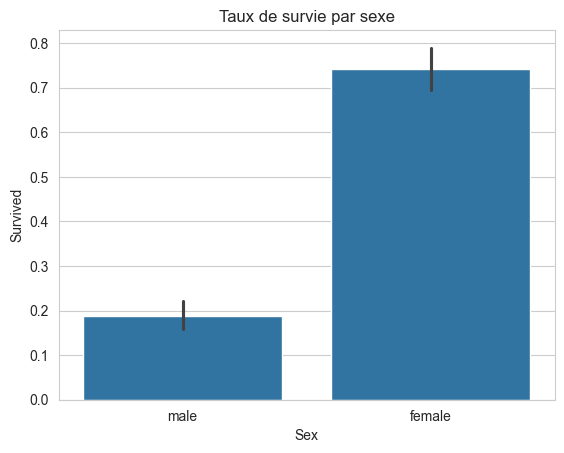

In [13]:
sns.barplot(data=train, x='Sex', y='Survived')
plt.title("Taux de survie par sexe")
plt.show()


In [ ]:
#analyse
Le taux de survie des femmes est bien plus haut que celui des hommes

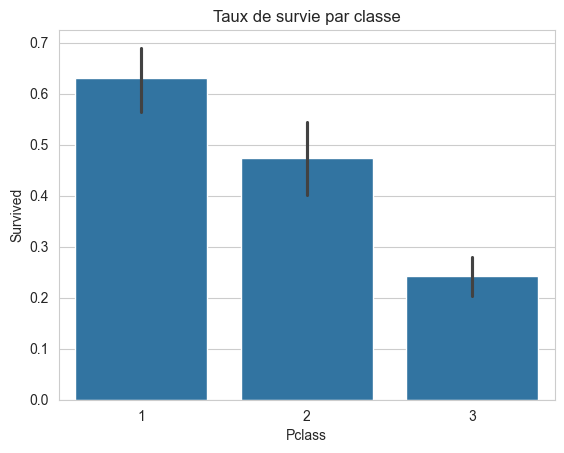

In [14]:
sns.barplot(data=train, x='Pclass', y='Survived')
plt.title("Taux de survie par classe")
plt.show()


In [15]:
On peut déduire que les premiere classe ont été secourus en premier puis deuxime classe et enfin 3ème

SyntaxError: invalid syntax (1047822211.py, line 1)

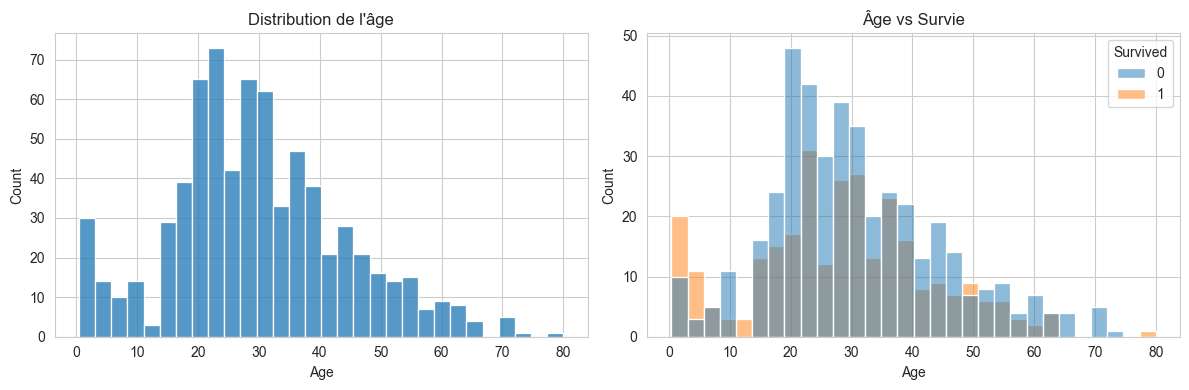

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['Age'].dropna(), bins=30, ax=axes[0])
axes[0].set_title("Distribution de l'âge")
sns.histplot(data=train, x='Age', hue='Survived', bins=30, ax=axes[1])
axes[1].set_title("Âge vs Survie")
plt.tight_layout()
plt.show()


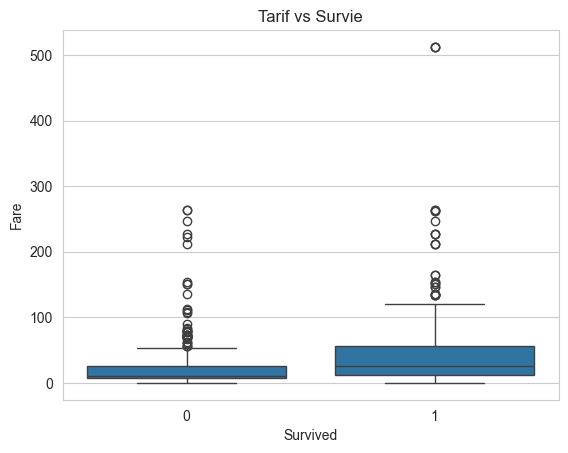

In [17]:
sns.boxplot(data=train, x='Survived', y='Fare')
plt.title("Tarif vs Survie")
plt.show()

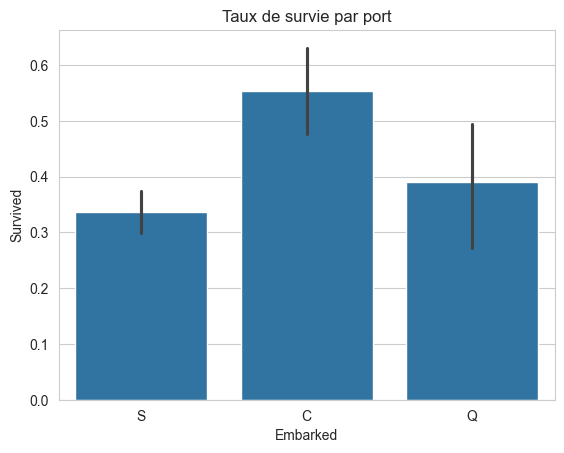

In [18]:
sns.barplot(data=train, x='Embarked', y='Survived')
plt.title("Taux de survie par port")
plt.show()

In [19]:
Les femmes avaient un taux de survie beaucoup plus élevé, 0,73% des survivants étaient des femmes.

SyntaxError: invalid syntax (1998304878.py, line 1)

In [ ]:
taux de survie décroissant de la 1ère à la 3ème classe (~60% → ~25%) (cellule 8). → Forte corrélation avec la survie, à garder.
    

In [21]:
Age : les enfants (<10 ans) semblent sur-représentés chez les survivants (cellule 9). → Garder Age, peut-être créer une feature "IsChild".

SyntaxError: invalid character '→' (U+2192) (1641811901.py, line 1)